# 1. Imports & Setup

# 2. Data Loading

# 3. Data Preprocessing

# 4. Shallow Neural Network

# 5. Deep Neural Network

# 6. Visualizations & Comparison

# 7. Performance Analysis

In [11]:
# Install any missing packages
!pip install torch torchvision --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('✅ All libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')

✅ All libraries imported successfully!
PyTorch version: 2.11.0+cpu


In [12]:
# ✅ Dataset fetched automatically from GitHub — no manual upload needed
RAW_URL = 'https://raw.githubusercontent.com/galib603147-arch/ML_Lab_5/refs/heads/main/Churn_Modelling.csv'

df = pd.read_csv(RAW_URL)
print(f'✅ Dataset loaded! Shape: {df.shape}')
df.head()

✅ Dataset loaded! Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
print('='*55)
print('DATASET OVERVIEW')
print('='*55)
print(f'Rows: {df.shape[0]}   |   Columns: {df.shape[1]}')
print()
print('Column Info:')
print(df.dtypes)
print()
print('Missing Values:')
print(df.isnull().sum())

DATASET OVERVIEW
Rows: 10000   |   Columns: 14

Column Info:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [14]:
print('Basic Statistics:')
df.describe()

Basic Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


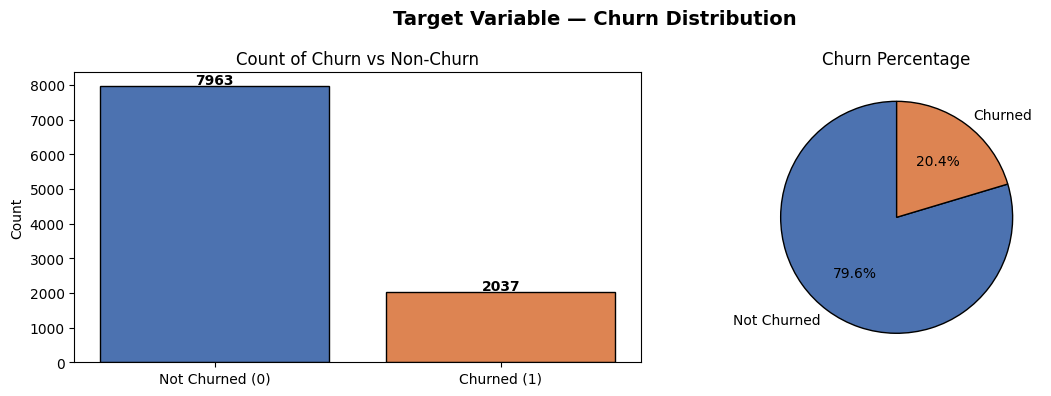

Class balance — Churned: 2037 (20.4%)  |  Not Churned: 7963 (79.6%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable — Churn Distribution', fontsize=14, fontweight='bold')

churn_counts = df['Exited'].value_counts()
colors = ['#4C72B0', '#DD8452']

axes[0].bar(['Not Churned (0)', 'Churned (1)'], churn_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Count of Churn vs Non-Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()
print(f'Class balance — Churned: {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)  |  Not Churned: {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)')

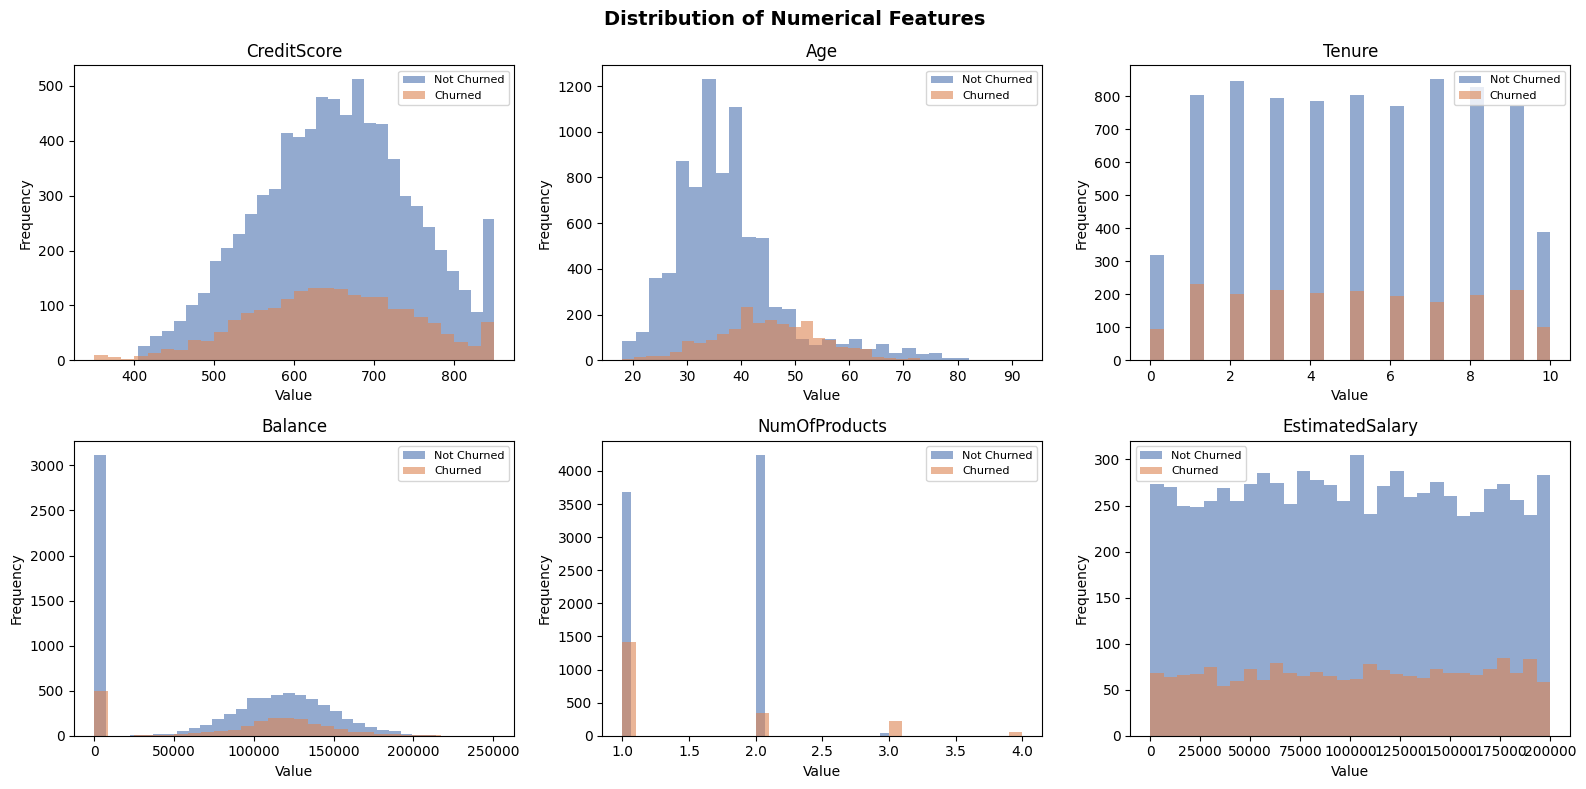

In [16]:
# ── 2.2  Numerical features distribution ────────────────────────────────────
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Exited']==0][col], bins=30, alpha=0.6, color='#4C72B0', label='Not Churned')
    axes[i].hist(df[df['Exited']==1][col], bins=30, alpha=0.6, color='#DD8452', label='Churned')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

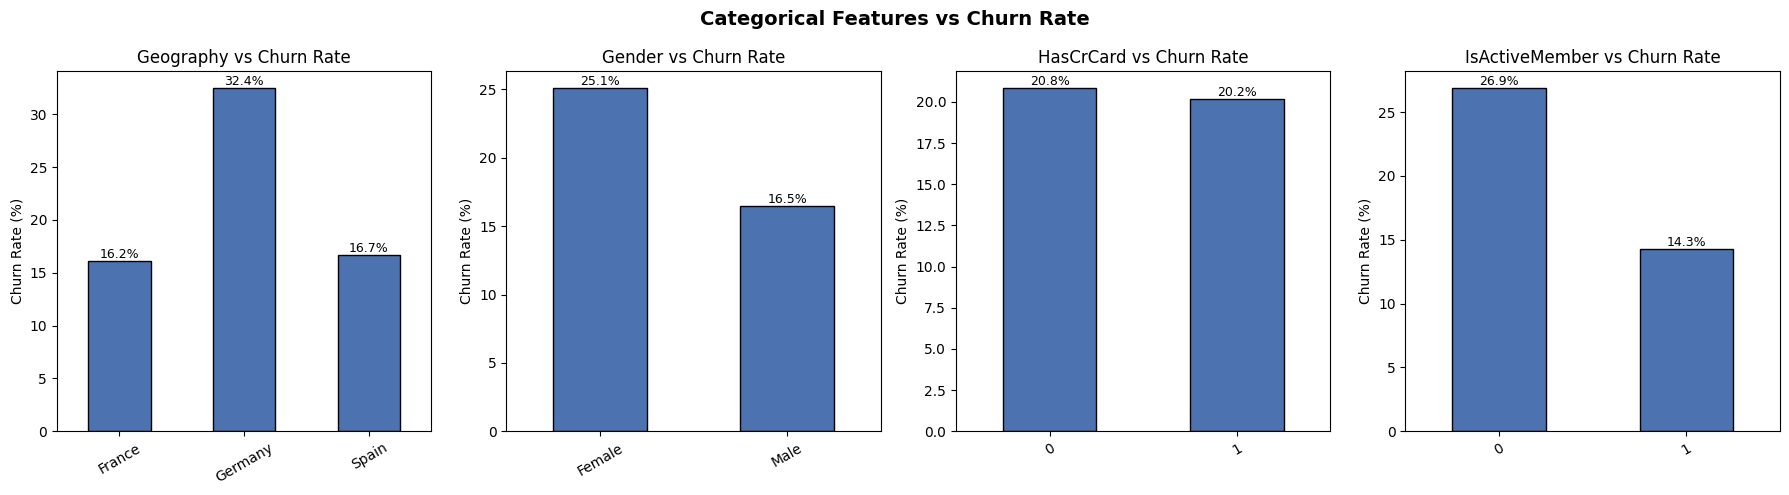

In [17]:
# ── 2.3  Categorical features vs Churn ──────────────────────────────────────
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Categorical Features vs Churn Rate', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[i], color='#4C72B0', edgecolor='black')
    axes[i].set_title(f'{col} vs Churn Rate')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%',
                         (p.get_x() + p.get_width()/2, p.get_height()),
                         ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

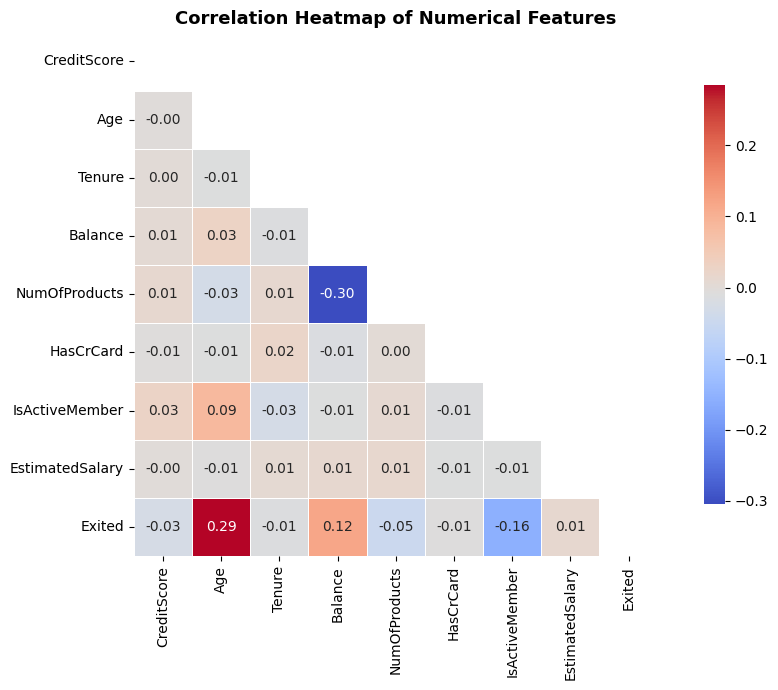

In [18]:
# ── 2.4  Correlation heatmap ─────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

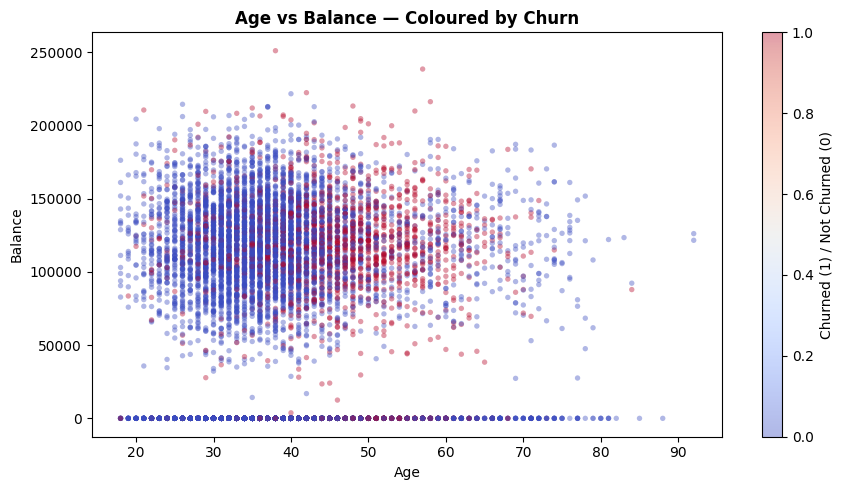

In [19]:
# ── 2.5  Age vs Balance scatter coloured by Churn ───────────────────────────
plt.figure(figsize=(9, 5))
scatter = plt.scatter(df['Age'], df['Balance'],
                      c=df['Exited'], cmap='coolwarm',
                      alpha=0.4, edgecolors='none', s=15)
plt.colorbar(scatter, label='Churned (1) / Not Churned (0)')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.title('Age vs Balance — Coloured by Churn', fontweight='bold')
plt.tight_layout()
plt.show()

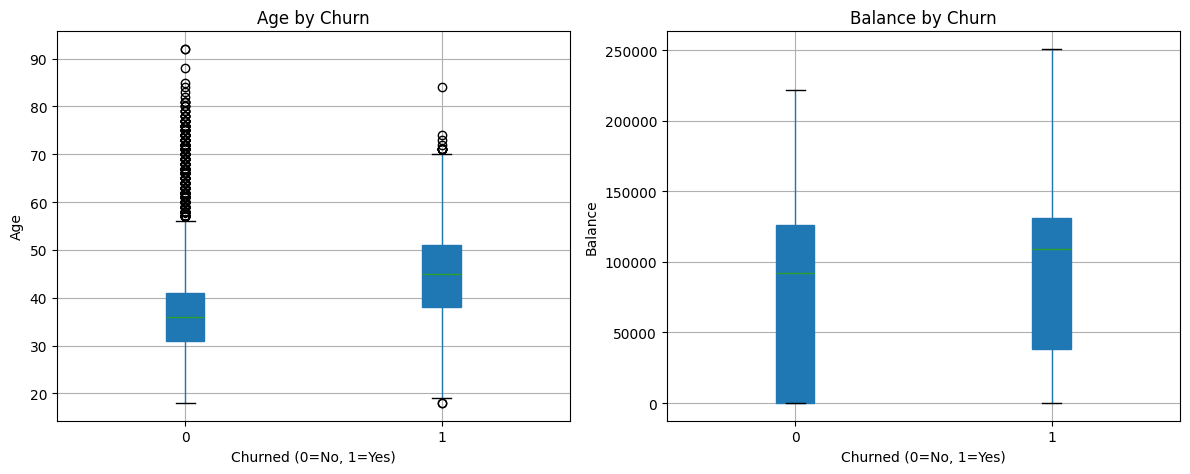

In [20]:
# ── 2.6  Box plots — Age & Balance by Churn ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Box Plots — Key Features by Churn Status', fontsize=13, fontweight='bold')

df.boxplot(column='Age', by='Exited', ax=axes[0], patch_artist=True)
axes[0].set_title('Age by Churn')
axes[0].set_xlabel('Churned (0=No, 1=Yes)')
axes[0].set_ylabel('Age')

df.boxplot(column='Balance', by='Exited', ax=axes[1], patch_artist=True)
axes[1].set_title('Balance by Churn')
axes[1].set_xlabel('Churned (0=No, 1=Yes)')
axes[1].set_ylabel('Balance')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [21]:
# Drop irrelevant columns
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Handle missing values (none in this dataset, but impute just in case)
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# One-Hot encode Geography; Ordinal encode Gender
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=False)
df_clean['Gender'] = LabelEncoder().fit_transform(df_clean['Gender'])  # Female=0, Male=1

# Convert boolean OHE columns to int
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print('Preprocessed shape:', df_clean.shape)
print('Columns:', list(df_clean.columns))
df_clean.head(3)

Preprocessed shape: (10000, 13)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0


In [22]:
# Features & Target
X = df_clean.drop('Exited', axis=1).values.astype(np.float32)
y = df_clean['Exited'].values.astype(np.float32)

# Stratified 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Further split train into train/val (80/20 of train)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

# Convert to PyTorch tensors
def to_tensors(X, y):
    return TensorDataset(torch.tensor(X, dtype=torch.float32),
                         torch.tensor(y, dtype=torch.float32))

train_ds = to_tensors(X_train, y_train)
val_ds   = to_tensors(X_val,   y_val)
test_ds  = to_tensors(X_test,  y_test)

INPUT_DIM = X_train.shape[1]
print(f'Input features: {INPUT_DIM}')

Train: (6400, 12)  |  Val: (1600, 12)  |  Test: (2000, 12)
Input features: 12


In [23]:
# ── Hyperparameter tuning grid ───────────────────────────────────────────────
# We tune: hidden_units, activation, batch_size
import itertools

shallow_grid = {
    'hidden_units': [32, 64, 128],
    'activation':   ['relu', 'sigmoid'],
    'batch_size':   [32, 64]
}

class ShallowNN(nn.Module):
    def __init__(self, input_dim, hidden_units, activation):
        super().__init__()
        act_fn = nn.ReLU() if activation == 'relu' else nn.Sigmoid()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            act_fn,
            nn.Linear(hidden_units, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def train_model(model, train_ds, val_ds, batch_size, epochs=30, lr=1e-3):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=256)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(yb)
            t_correct += ((out >= 0.5).float() == yb).sum().item()
            t_total += len(yb)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                out = model(Xb)
                loss = criterion(out, yb)
                v_loss += loss.item() * len(yb)
                v_correct += ((out >= 0.5).float() == yb).sum().item()
                v_total += len(yb)

        history['train_loss'].append(t_loss / t_total)
        history['val_loss'].append(v_loss / v_total)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(v_correct / v_total)

    return history

# Tune shallow NN
best_shallow = {'val_acc': 0}
print('Tuning Shallow NN...')
for hu, act, bs in itertools.product(
        shallow_grid['hidden_units'],
        shallow_grid['activation'],
        shallow_grid['batch_size']):
    model = ShallowNN(INPUT_DIM, hu, act)
    hist  = train_model(model, train_ds, val_ds, batch_size=bs, epochs=30)
    final_val_acc = hist['val_acc'][-1]
    if final_val_acc > best_shallow['val_acc']:
        best_shallow = {'val_acc': final_val_acc, 'model': model,
                        'history': hist, 'hidden_units': hu,
                        'activation': act, 'batch_size': bs}

print(f"\n✅ Best Shallow NN Config:")
print(f"   Hidden Units : {best_shallow['hidden_units']}")
print(f"   Activation   : {best_shallow['activation']}")
print(f"   Batch Size   : {best_shallow['batch_size']}")
print(f"   Val Accuracy : {best_shallow['val_acc']:.4f}")

Tuning Shallow NN...

✅ Best Shallow NN Config:
   Hidden Units : 64
   Activation   : relu
   Batch Size   : 64
   Val Accuracy : 0.8588


In [24]:
# ── Hyperparameter tuning grid ───────────────────────────────────────────────
deep_grid = {
    'lr':        [1e-3, 5e-4],
    'optimizer': ['adam', 'sgd'],
    'epochs':    [50, 80]
}

class DeepNN(nn.Module):
    def __init__(self, input_dim, dropout=0.3):
        super().__init__()
        # 4 hidden layers with Dropout (L2 via weight_decay in optimizer)
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64,  32),        nn.ReLU(),
            nn.Linear(32,  1),         nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

def train_model_deep(model, train_ds, val_ds, lr, opt_name, epochs):
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=256)
    criterion    = nn.BCELoss()
    if opt_name == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * len(yb)
            t_correct += ((out >= 0.5).float() == yb).sum().item()
            t_total += len(yb)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                out = model(Xb)
                loss = criterion(out, yb)
                v_loss += loss.item() * len(yb)
                v_correct += ((out >= 0.5).float() == yb).sum().item()
                v_total += len(yb)

        history['train_loss'].append(t_loss / t_total)
        history['val_loss'].append(v_loss / v_total)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(v_correct / v_total)

    return history

# Tune deep NN
best_deep = {'val_acc': 0}
print('Tuning Deep NN...')
for lr, opt, ep in itertools.product(
        deep_grid['lr'],
        deep_grid['optimizer'],
        deep_grid['epochs']):
    model = DeepNN(INPUT_DIM, dropout=0.3)
    hist  = train_model_deep(model, train_ds, val_ds, lr=lr, opt_name=opt, epochs=ep)
    final_val_acc = hist['val_acc'][-1]
    if final_val_acc > best_deep['val_acc']:
        best_deep = {'val_acc': final_val_acc, 'model': model,
                     'history': hist, 'lr': lr,
                     'optimizer': opt, 'epochs': ep}

print(f"\n✅ Best Deep NN Config:")
print(f"   Learning Rate : {best_deep['lr']}")
print(f"   Optimizer     : {best_deep['optimizer']}")
print(f"   Epochs        : {best_deep['epochs']}")
print(f"   Val Accuracy  : {best_deep['val_acc']:.4f}")

Tuning Deep NN...

✅ Best Deep NN Config:
   Learning Rate : 0.0005
   Optimizer     : adam
   Epochs        : 80
   Val Accuracy  : 0.8625


In [25]:
def get_predictions(model, dataset):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)
    probs, labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            probs.append(model(Xb).numpy())
            labels.append(yb.numpy())
    probs  = np.concatenate(probs)
    labels = np.concatenate(labels)
    preds  = (probs >= 0.5).astype(int)
    return probs, preds, labels

s_probs, s_preds, y_true = get_predictions(best_shallow['model'], test_ds)
d_probs, d_preds, _      = get_predictions(best_deep['model'],    test_ds)

print('✅ Test predictions generated!')

✅ Test predictions generated!


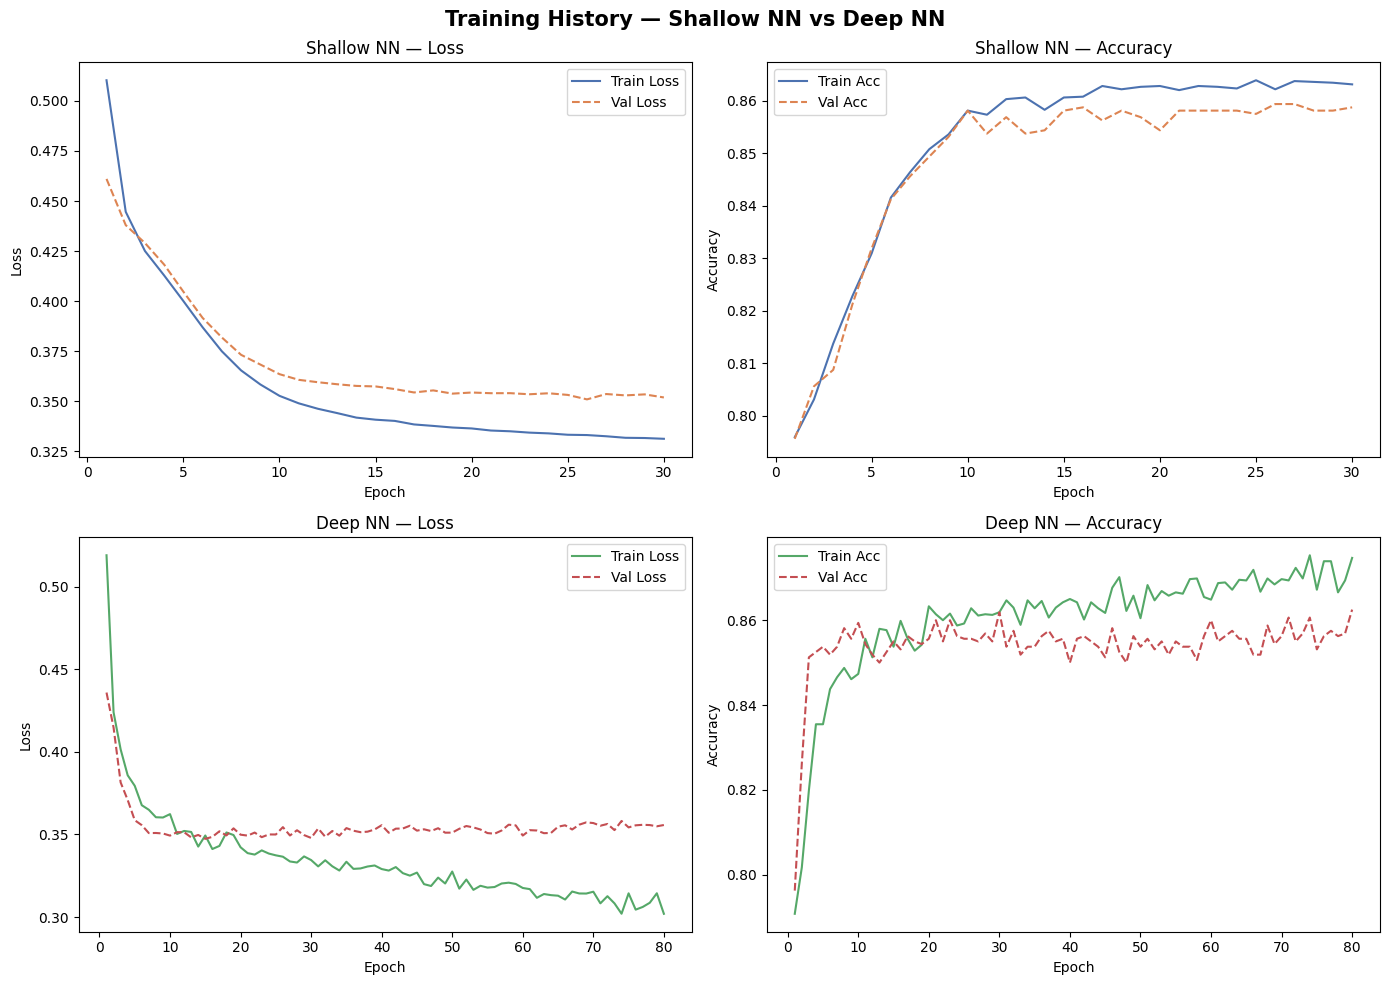

In [26]:
s_hist = best_shallow['history']
d_hist = best_deep['history']
s_ep   = range(1, len(s_hist['train_loss']) + 1)
d_ep   = range(1, len(d_hist['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Shallow NN vs Deep NN', fontsize=15, fontweight='bold')

# Shallow — Loss
axes[0, 0].plot(s_ep, s_hist['train_loss'], label='Train Loss', color='#4C72B0')
axes[0, 0].plot(s_ep, s_hist['val_loss'],   label='Val Loss',   color='#DD8452', linestyle='--')
axes[0, 0].set_title('Shallow NN — Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Shallow — Accuracy
axes[0, 1].plot(s_ep, s_hist['train_acc'], label='Train Acc', color='#4C72B0')
axes[0, 1].plot(s_ep, s_hist['val_acc'],   label='Val Acc',   color='#DD8452', linestyle='--')
axes[0, 1].set_title('Shallow NN — Accuracy')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Deep — Loss
axes[1, 0].plot(d_ep, d_hist['train_loss'], label='Train Loss', color='#55A868')
axes[1, 0].plot(d_ep, d_hist['val_loss'],   label='Val Loss',   color='#C44E52', linestyle='--')
axes[1, 0].set_title('Deep NN — Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

# Deep — Accuracy
axes[1, 1].plot(d_ep, d_hist['train_acc'], label='Train Acc', color='#55A868')
axes[1, 1].plot(d_ep, d_hist['val_acc'],   label='Val Acc',   color='#C44E52', linestyle='--')
axes[1, 1].set_title('Deep NN — Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

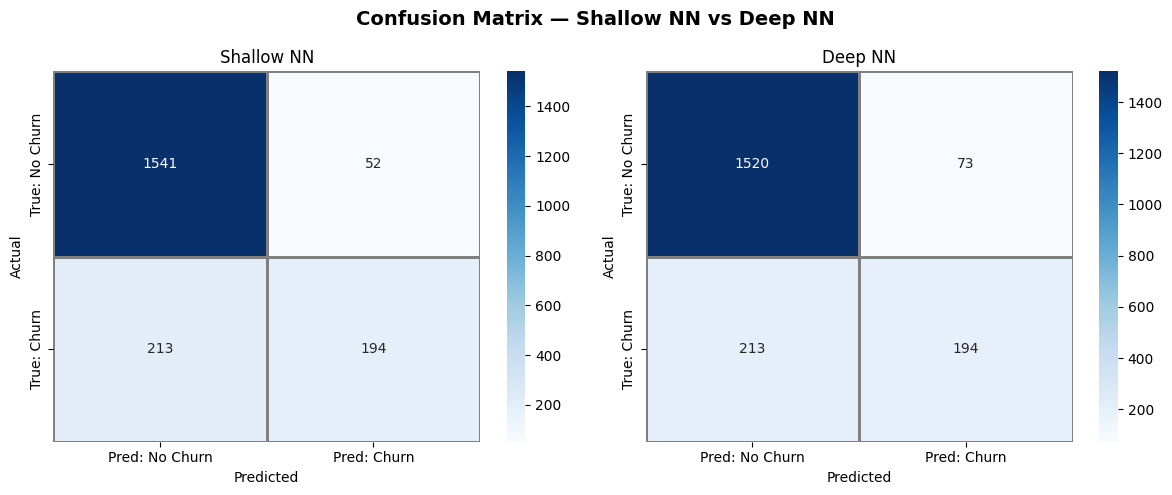

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrix — Shallow NN vs Deep NN', fontsize=14, fontweight='bold')

for ax, preds, title in zip(axes,
                             [s_preds, d_preds],
                             ['Shallow NN', 'Deep NN']):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No Churn', 'Pred: Churn'],
                yticklabels=['True: No Churn', 'True: Churn'],
                linewidths=1, linecolor='gray')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Shallow NN AUC Score: 0.8569
Deep NN AUC Score: 0.8594


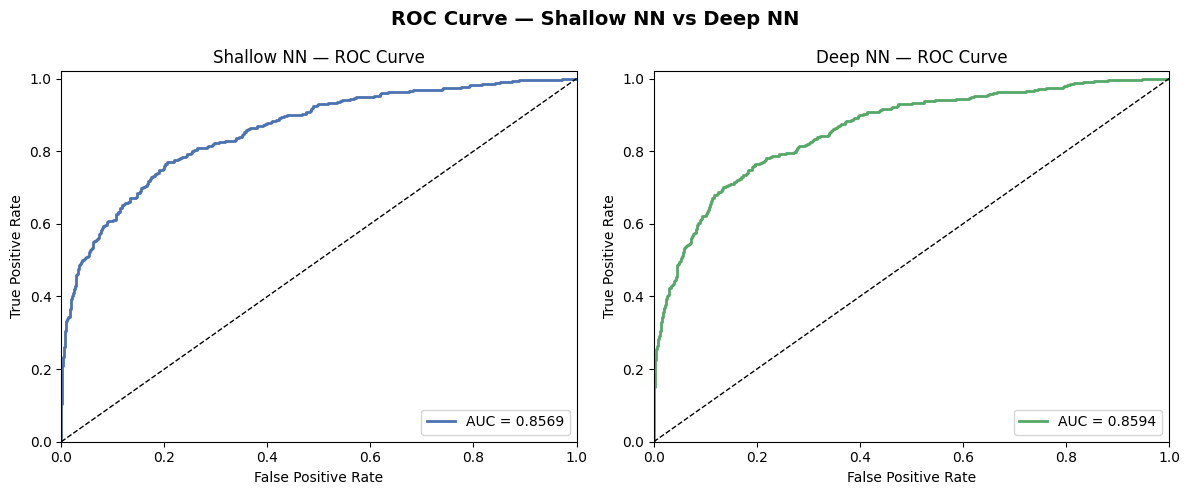

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('ROC Curve — Shallow NN vs Deep NN', fontsize=14, fontweight='bold')

for ax, probs, title, color in zip(axes,
                                    [s_probs, d_probs],
                                    ['Shallow NN', 'Deep NN'],
                                    ['#4C72B0', '#55A868']):
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} — ROC Curve', fontsize=12)
    ax.legend(loc='lower right')
    print(f'{title} AUC Score: {roc_auc:.4f}')

plt.tight_layout()
plt.show()

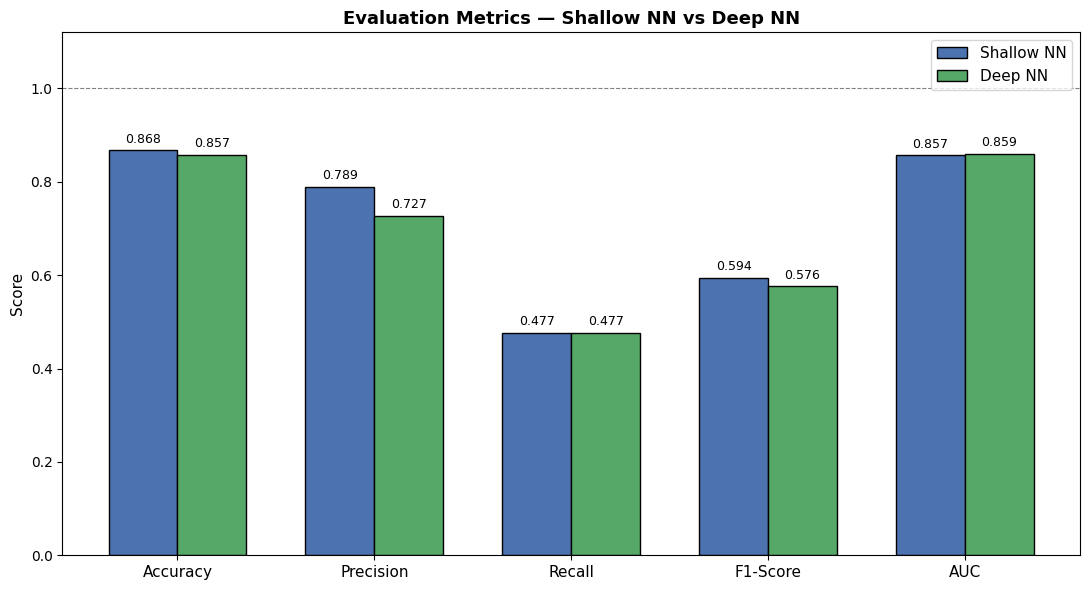


📋 Metrics Table:
           Shallow NN   Deep NN
Accuracy     0.867500  0.857000
Precision    0.788618  0.726592
Recall       0.476658  0.476658
F1-Score     0.594181  0.575668
AUC          0.856851  0.859417


In [29]:
def get_metrics(y_true, preds, probs):
    return {
        'Accuracy':  accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall':    recall_score(y_true, preds, zero_division=0),
        'F1-Score':  f1_score(y_true, preds, zero_division=0),
        'AUC':       roc_auc_score(y_true, probs)
    }

s_metrics = get_metrics(y_true, s_preds, s_probs)
d_metrics = get_metrics(y_true, d_preds, d_probs)

metric_names = list(s_metrics.keys())
s_vals = list(s_metrics.values())
d_vals = list(d_metrics.values())

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, s_vals, width, label='Shallow NN', color='#4C72B0', edgecolor='black')
bars2 = ax.bar(x + width/2, d_vals, width, label='Deep NN',    color='#55A868', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Evaluation Metrics — Shallow NN vs Deep NN', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\n📋 Metrics Table:')
metrics_df = pd.DataFrame({'Shallow NN': s_metrics, 'Deep NN': d_metrics})
print(metrics_df.to_string())

In [30]:
def print_arch_table(model, name):
    print(f'\n{'='*55}')
    print(f'  Architecture: {name}')
    print(f'{'='*55}')
    print(f'  {"Layer":<30} {"Output Shape":<15} {"Params"}')
    print(f'  {"-"*55}')
    total_params = 0
    for name_layer, module in model.named_modules():
        if isinstance(module, (nn.Linear, nn.Dropout, nn.BatchNorm1d, nn.ReLU, nn.Sigmoid)):
            params = sum(p.numel() for p in module.parameters())
            total_params += params
            layer_type = module.__class__.__name__
            if isinstance(module, nn.Linear):
                shape = f'({module.out_features},)'
            elif isinstance(module, nn.BatchNorm1d):
                shape = f'({module.num_features},)'
            elif isinstance(module, nn.Dropout):
                shape = f'(p={module.p})'
            else:
                shape = '—'
            print(f'  {layer_type:<30} {shape:<15} {params}')
    print(f'  {"-"*55}')
    print(f'  Total Trainable Parameters: {total_params:,}')

print_arch_table(best_shallow['model'], 'Shallow Neural Network')
print_arch_table(best_deep['model'],    'Deep Neural Network')


  Architecture: Shallow Neural Network
  Layer                          Output Shape    Params
  -------------------------------------------------------
  Linear                         (64,)           832
  ReLU                           —               0
  Linear                         (1,)            65
  Sigmoid                        —               0
  -------------------------------------------------------
  Total Trainable Parameters: 897

  Architecture: Deep Neural Network
  Layer                          Output Shape    Params
  -------------------------------------------------------
  Linear                         (256,)          3328
  BatchNorm1d                    (256,)          512
  ReLU                           —               0
  Dropout                        (p=0.3)         0
  Linear                         (128,)          32896
  BatchNorm1d                    (128,)          256
  ReLU                           —               0
  Dropout                   

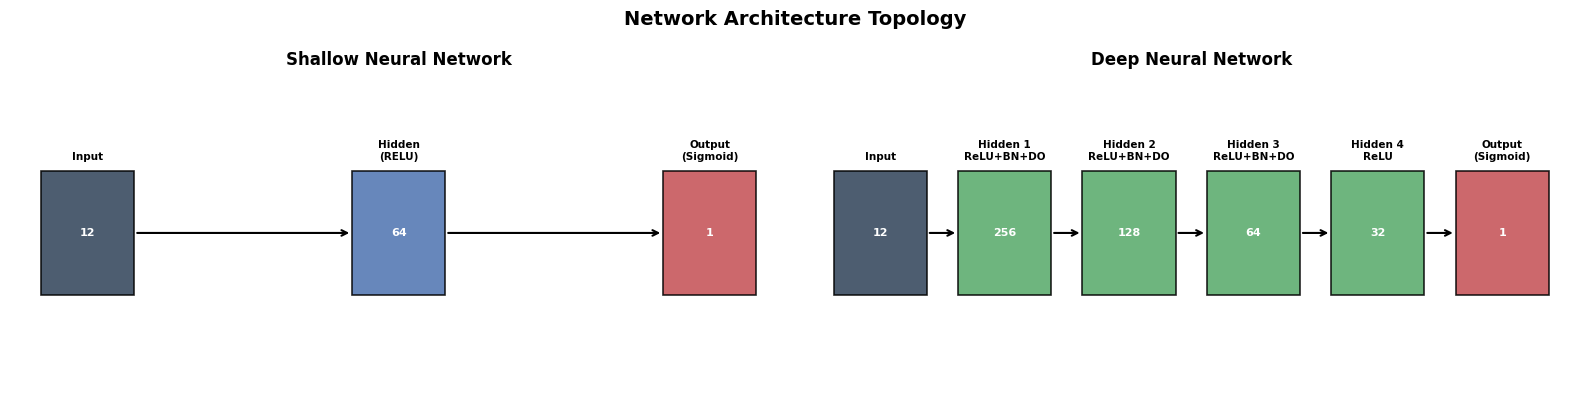

In [31]:
# ── Visual topology diagram ──────────────────────────────────────────────────
def draw_topology(ax, layers, title, colors):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    n = len(layers)
    xs = np.linspace(0.1, 0.9, n)
    for i, (x, (lname, lsize)) in enumerate(zip(xs, layers)):
        ax.add_patch(plt.Rectangle((x-0.06, 0.3), 0.12, 0.4,
                                    color=colors[i % len(colors)],
                                    alpha=0.85, ec='black', lw=1.2))
        ax.text(x, 0.73, lname, ha='center', va='bottom', fontsize=7.5, fontweight='bold')
        ax.text(x, 0.5,  lsize, ha='center', va='center', fontsize=8,   color='white', fontweight='bold')
        if i < n - 1:
            ax.annotate('', xy=(xs[i+1]-0.06, 0.5), xytext=(x+0.06, 0.5),
                        arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

hu = best_shallow['hidden_units']
shallow_layers = [('Input', f'{INPUT_DIM}'), (f'Hidden\n({best_shallow["activation"].upper()})', f'{hu}'), ('Output\n(Sigmoid)', '1')]
deep_layers    = [('Input', f'{INPUT_DIM}'),
                  ('Hidden 1\nReLU+BN+DO', '256'),
                  ('Hidden 2\nReLU+BN+DO', '128'),
                  ('Hidden 3\nReLU+BN+DO', '64'),
                  ('Hidden 4\nReLU', '32'),
                  ('Output\n(Sigmoid)', '1')]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Network Architecture Topology', fontsize=14, fontweight='bold')

draw_topology(axes[0], shallow_layers, 'Shallow Neural Network',
              ['#2E4057', '#4C72B0', '#C44E52'])
draw_topology(axes[1], deep_layers,    'Deep Neural Network',
              ['#2E4057', '#55A868', '#55A868', '#55A868', '#55A868', '#C44E52'])

plt.tight_layout()
plt.show()

In [32]:
print('\n🎉 Notebook completed successfully!')
print('All visualizations rendered. No manual intervention was required.')


🎉 Notebook completed successfully!
All visualizations rendered. No manual intervention was required.
